# Data exploration

Sanity-check the dataset: what a (field, hologram) pair looks like, and that
the physics forward model (`src/physics.py`) actually reproduces real
measured holograms before trusting it for self-supervised training.

In [1]:
import sys
sys.path.insert(0, '../src')
import matplotlib.pyplot as plt
import torch

from datasets import HologramFieldDataset
from physics import field_to_hologram

DATA_ROOT = r'D:\Graduate Study\AI in biomed imaging\Bio_image\MicroDegree\Data'
ds = HologramFieldDataset(DATA_ROOT, 'train')
print(f'{len(ds)} train pairs')
holo, amp, pha = ds[0]
print('shapes:', holo.shape, amp.shape, pha.shape)

1500 train pairs
shapes: torch.Size([1, 256, 256]) torch.Size([1, 256, 256]) torch.Size([1, 256, 256])


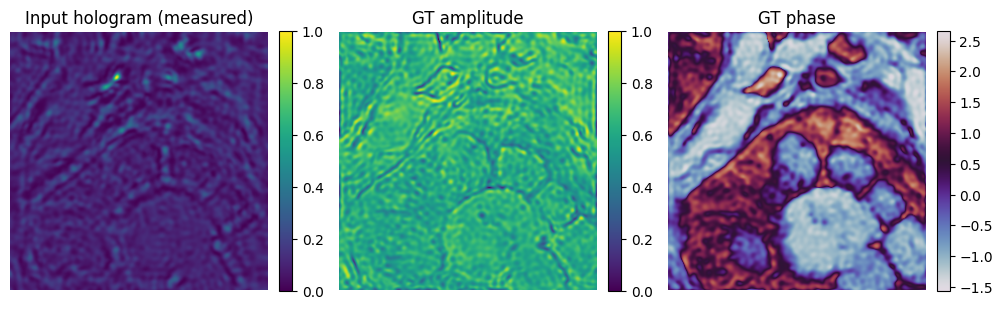

In [2]:
fig, axes = plt.subplots(1, 3, figsize=(10, 3.3))
panels = [(holo[0], 'Input hologram (measured)', 'viridis'),
          (amp[0], 'GT amplitude', 'viridis'),
          (pha[0], 'GT phase', 'twilight')]
for ax, (img, title, cmap) in zip(axes, panels):
    im = ax.imshow(img, cmap=cmap); ax.set_title(title); ax.axis('off')
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
fig.tight_layout()

## Physics forward model sanity check

Propagate the ground-truth field with our ASM implementation at the same
distance (10mm) the real hologram was measured at, and compare.

Pearson correlation (real vs. simulated hologram): 0.9975


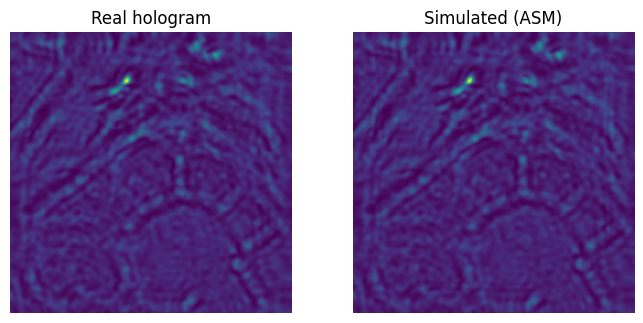

In [3]:
import numpy as np

dist = torch.tensor([10.0])
sim_holo = field_to_hologram(amp.unsqueeze(0), pha.unsqueeze(0), dist)[0]

corr = np.corrcoef(holo[0].numpy().flatten(), sim_holo[0].numpy().flatten())[0, 1]
print(f'Pearson correlation (real vs. simulated hologram): {corr:.4f}')

fig, axes = plt.subplots(1, 2, figsize=(7, 3.3))
axes[0].imshow(holo[0], cmap='viridis'); axes[0].set_title('Real hologram')
axes[1].imshow(sim_holo[0], cmap='viridis'); axes[1].set_title('Simulated (ASM)')
for ax in axes: ax.axis('off')
fig.tight_layout()